# 2.1 - State Analysis & Model Selection
Research and analyze data links and distributions in order to choose wisely the one that could permorm the best with the particularities of the data

## 1: Dependencies and Imports

In [1]:
# Standard library
import os

# Third-party
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## 2: Load Data

In [2]:
# Path to the integrated master dataset
data_path = '../data/Filtered.pkl'

if os.path.exists(data_path):
    # Load the integrated dataframe
    df = pd.read_pickle(data_path)
else:
    print(f"Error: File not found at {data_path}")

df.info()
display(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 114567 entries, 0 to 119142
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        114567 non-null  object 
 1   is_delayed                      114567 non-null  int64  
 2   actual_delivery_days            114567 non-null  float64
 3   estimated_delivery_margin_days  114567 non-null  int64  
 4   purchase_month                  114567 non-null  int32  
 5   purchase_day_of_week            114567 non-null  int32  
 6   product_weight_g                114567 non-null  float64
 7   product_volume_cm3              114567 non-null  float64
 8   product_category_name_english   114567 non-null  object 
 9   customer_zip_code_prefix        114567 non-null  int64  
 10  seller_zip_code_prefix          114567 non-null  float64
 11  is_same_state                   114567 non-null  int64  
 12  customer_state_num_pr

,order_id,is_delayed,actual_delivery_days,estimated_delivery_margin_days,purchase_month,purchase_day_of_week,product_weight_g,product_volume_cm3,product_category_name_english,customer_zip_code_prefix,seller_zip_code_prefix,is_same_state,customer_state_num_pred,seller_state_num_pred,freight_value,price
0,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
1,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
2,e481f51cbdc54678b7cc49136f2d6af7,0,8.0,15,10,0,500.0,1976.0,housewares,3149,9350.0,1,25,25,8.72,29.99
3,53cdb2fc8bc7dce0b6741e2150273451,0,13.0,19,7,1,400.0,4693.0,perfumery,47813,31570.0,0,4,25,22.76,118.70
4,47770eb9100c2d0c44946d9cf07ec65d,0,9.0,26,8,2,420.0,9576.0,auto,75265,14840.0,0,8,25,19.22,159.90


## 3: Target Analysis

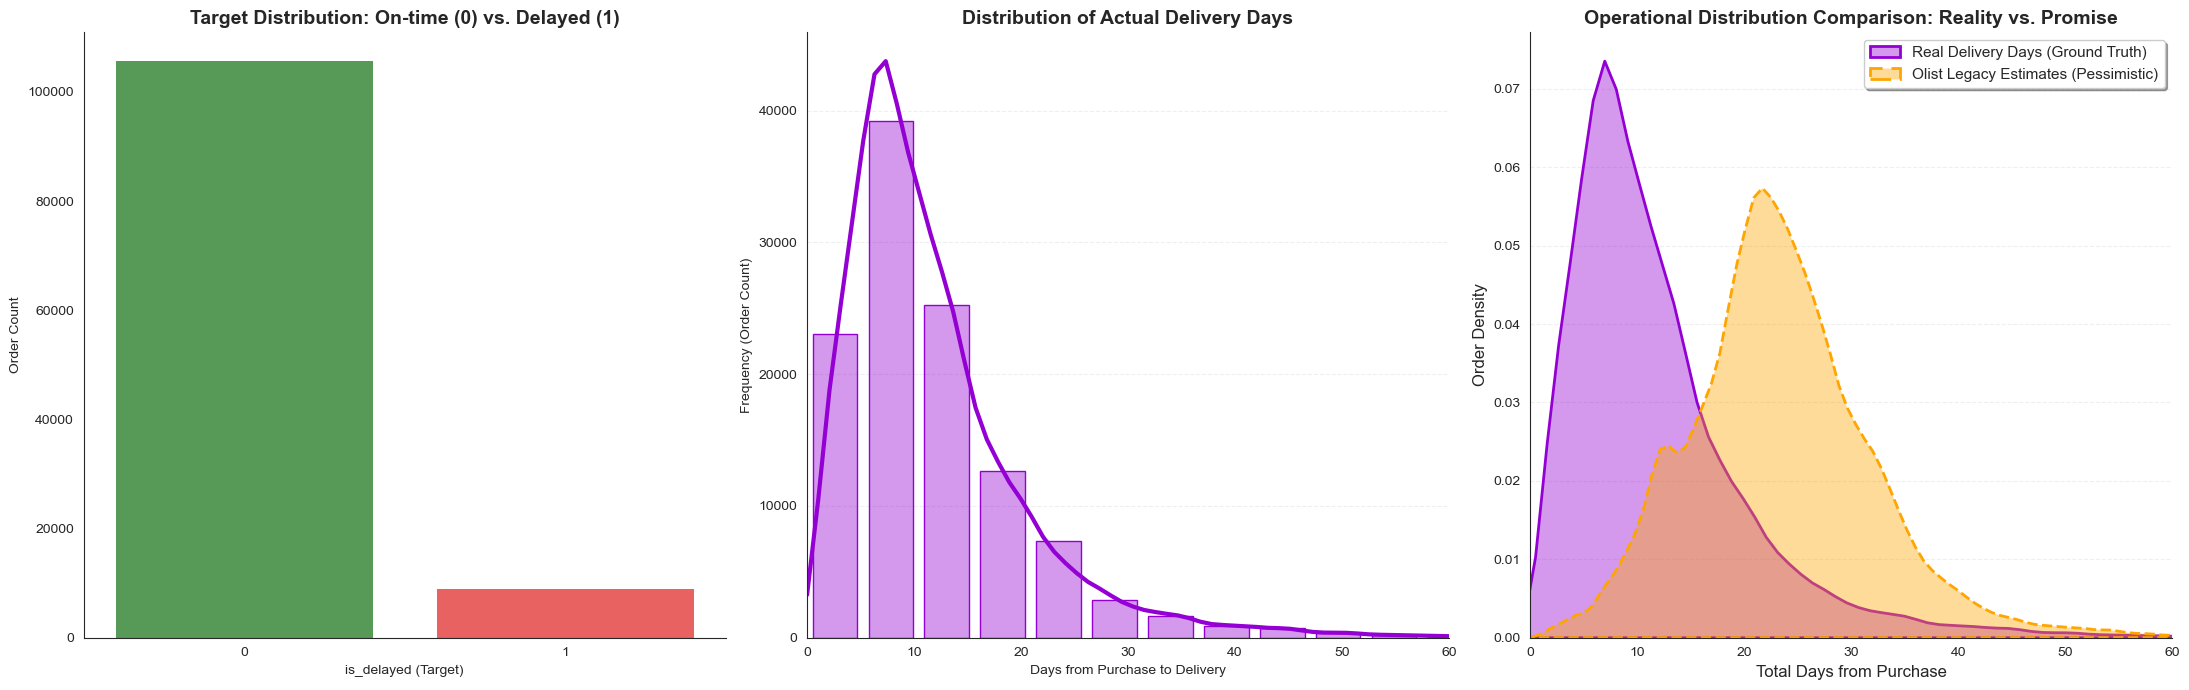

Statistical Analysis of Delivery Performance:
 - Mean Delivery Time:      11.99 days
 - Median (50th Percentile): 10.00 days
 - Standard Deviation (sigma):  9.41 days


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global aesthetic setup
sns.set_style("white")

# Initialize a multi-panel figure
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(22, 7))

# PLOT 1: Target Class Balance
sns.countplot(
    data=df, 
    x='is_delayed', 
    hue='is_delayed', 
    palette=['green', 'red'], 
    ax=ax1,
    alpha=0.7,
    linewidth=0 # Removed outline
)
ax1.set_title('Target Distribution: On-time (0) vs. Delayed (1)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Order Count')
ax1.set_xlabel('is_delayed (Target)')
if ax1.get_legend() is not None: 
    ax1.get_legend().remove()

# PLOT 2: Actual Delivery Timeline
delivery_days = df['actual_delivery_days']
sns.histplot(
    delivery_days, 
    bins=40, 
    kde=True, 
    color='DarkViolet', 
    ax=ax2,
    alpha=0.4,
    shrink=0.8, # Slightly separated bars
    edgecolor='DarkViolet',
    linewidth=1,
    line_kws={'linewidth': 3} 
)
ax2.set_title('Distribution of Actual Delivery Days', fontweight='bold', fontsize=14)
ax2.set_xlabel('Days from Purchase to Delivery')
ax2.set_ylabel('Frequency (Order Count)')
ax2.set_xlim(0, 60)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# PLOT 3: Operational Distribution Comparison
sns.kdeplot(
    data=df, x='actual_delivery_days', 
    fill=True, color="DarkViolet", label="Real Delivery Days (Ground Truth)", 
    alpha=0.4, ax=ax3, linewidth=2
)

sns.kdeplot(
    data=df, x='estimated_delivery_margin_days', 
    fill=True, color="Orange", label="Olist Legacy Estimates (Pessimistic)", 
    alpha=0.4, ax=ax3, linewidth=2, linestyle='--'
)

ax3.set_title('Operational Distribution Comparison: Reality vs. Promise', fontsize=14, fontweight='bold')
ax3.set_xlabel('Total Days from Purchase', fontsize=12)
ax3.set_ylabel('Order Density', fontsize=12)
ax3.set_xlim(0, 60)
ax3.legend(fontsize=11, loc='upper right', frameon=True, shadow=True)
ax3.grid(axis='y', linestyle='--', alpha=0.3)

# Clean spines for a modern look
sns.despine()

plt.tight_layout()
plt.show()

# Summary Statistics
print("Statistical Analysis of Delivery Performance:")
print(f" - Mean Delivery Time:      {delivery_days.mean():.2f} days")
print(f" - Median (50th Percentile): {delivery_days.median():.2f} days")
print(f" - Standard Deviation (sigma):  {delivery_days.std():.2f} days")

## 4: Feature Analysis

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 114567 entries, 0 to 119142
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   order_id                        114567 non-null  object 
 1   is_delayed                      114567 non-null  int64  
 2   actual_delivery_days            114567 non-null  float64
 3   estimated_delivery_margin_days  114567 non-null  int64  
 4   purchase_month                  114567 non-null  int32  
 5   purchase_day_of_week            114567 non-null  int32  
 6   product_weight_g                114567 non-null  float64
 7   product_volume_cm3              114567 non-null  float64
 8   product_category_name_english   114567 non-null  object 
 9   customer_zip_code_prefix        114567 non-null  int64  
 10  seller_zip_code_prefix          114567 non-null  float64
 11  is_same_state                   114567 non-null  int64  
 12  customer_state_num_pr

In [5]:
# Visual style
sns.set_palette("viridis")

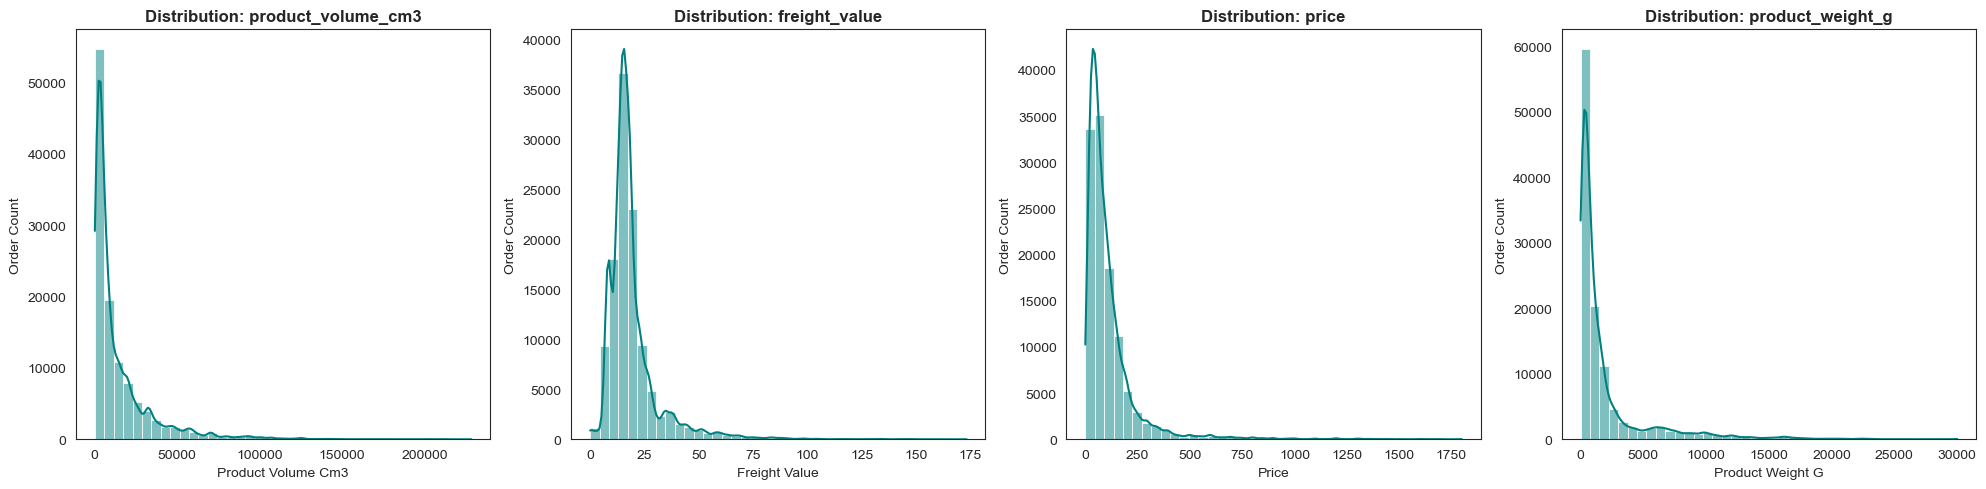

In [6]:
# Select key physical and economic continuous features
numeric_features = ['product_volume_cm3', 'freight_value', 'price', 'product_weight_g']

# Initialize subplots for distribution visualization
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, feature in enumerate(numeric_features):
    # Use histograms with Kernel Density Estimate (KDE) to visualize data distribution and skewness
    sns.histplot(df[feature], bins=40, kde=True, ax=axes[i], color='teal')
    
    axes[i].set_title(f'Distribution: {feature}', fontweight='bold')
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

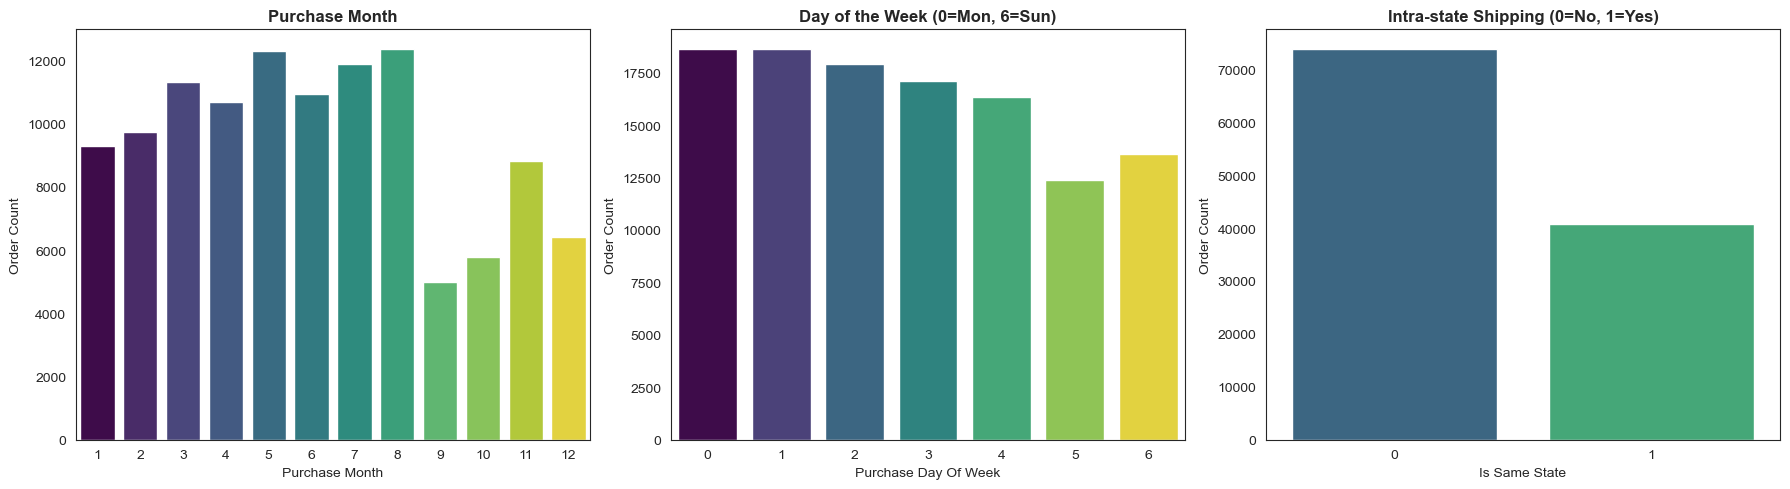

In [7]:
# Temporal And Operational Features
categorical_features = ['purchase_month', 'purchase_day_of_week', 'is_same_state']
feature_titles = [
    'Purchase Month', 
    'Day of the Week (0=Mon, 6=Sun)', 
    'Intra-state Shipping (0=No, 1=Yes)'
]

# Initialize subplots for frequency visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feature in enumerate(categorical_features):
    # Use countplots to observe frequency distributions and potential seasonal patterns
    sns.countplot(data=df, x=feature, ax=axes[i], palette='viridis', hue=feature, legend=False)
    
    axes[i].set_title(feature_titles[i], fontweight='bold')
    axes[i].set_xlabel(feature.replace('_', ' ').title())
    axes[i].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

## 5: General Analysis

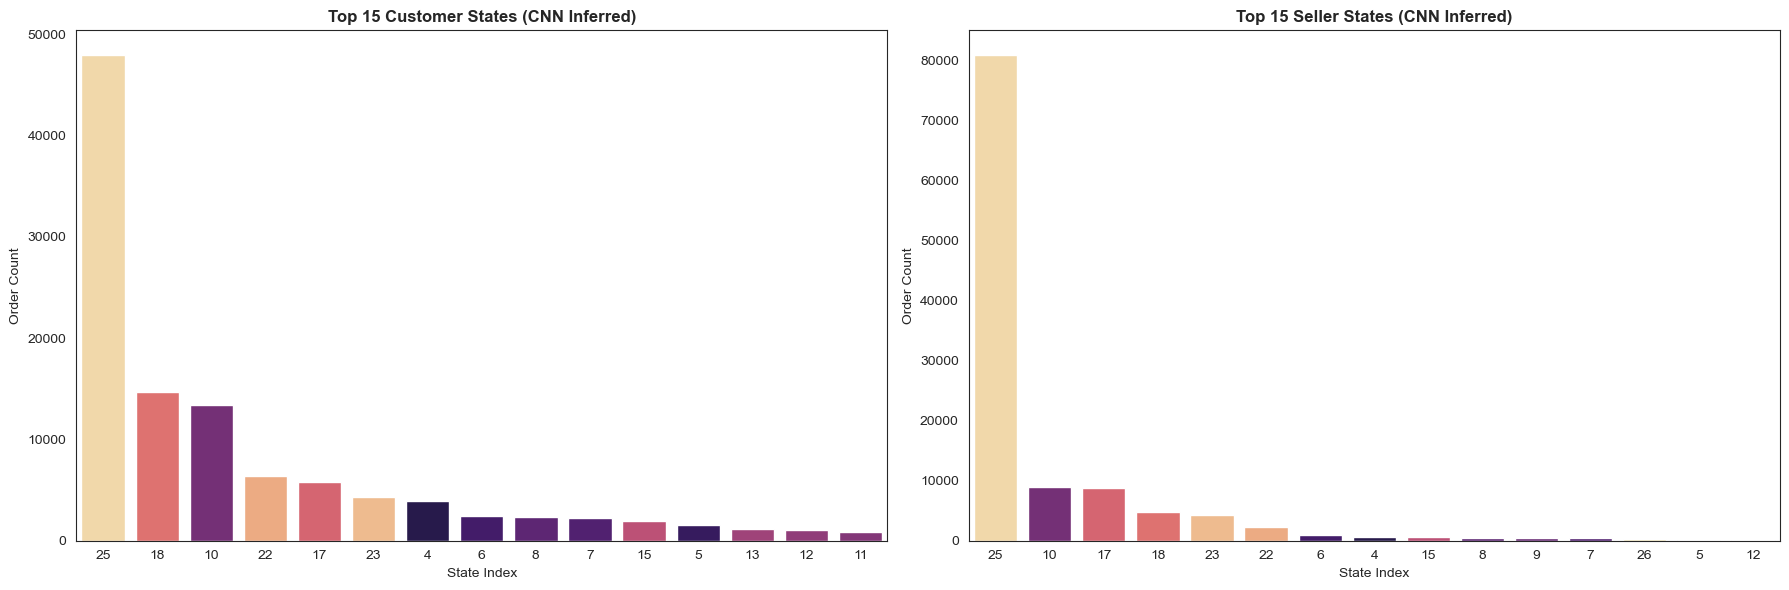

In [8]:
# Visualizing the distribution of the top 15 states to identify volume concentration
# We use the state indices inferred by the CNN model
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Plot 1: Customer State Distribution ---
sns.countplot(
    data=df, 
    x='customer_state_num_pred', 
    hue='customer_state_num_pred',
    order=df['customer_state_num_pred'].value_counts().index[:15], 
    ax=axes[0], 
    palette='magma', 
    legend=False
)
axes[0].set_title('Top 15 Customer States (CNN Inferred)', fontweight='bold')
axes[0].set_xlabel('State Index')
axes[0].set_ylabel('Order Count')

# --- Plot 2: Seller State Distribution ---
sns.countplot(
    data=df, 
    x='seller_state_num_pred', 
    hue='seller_state_num_pred',
    order=df['seller_state_num_pred'].value_counts().index[:15], 
    ax=axes[1], 
    palette='magma', 
    legend=False
)
axes[1].set_title('Top 15 Seller States (CNN Inferred)', fontweight='bold')
axes[1].set_xlabel('State Index')
axes[1].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

In [9]:
# Download and locate the geolocation dataset via kagglehub
dataset_path = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
geo_file_path = os.path.join(dataset_path, 'olist_geolocation_dataset.csv')
geolocation_df = pd.read_csv(geo_file_path)

# Simplify data
geo_centroids = geolocation_df.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()

# Integrate Geolocation for customers
integrated_df = pd.merge(
    df,
    geo_centroids, 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)

integrated_df.rename(columns={
    'geolocation_lat': 'customer_lat', 
    'geolocation_lng': 'customer_lng'
}, inplace=True)

integrated_df.drop('geolocation_zip_code_prefix', axis=1, inplace=True)

# Integrate Geolocation for vendors
integrated_df = pd.merge(
    integrated_df, 
    geo_centroids, 
    left_on='seller_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
)

integrated_df.rename(columns={
    'geolocation_lat': 'seller_lat', 
    'geolocation_lng': 'seller_lng'
}, inplace=True)

integrated_df.drop('geolocation_zip_code_prefix', axis=1, inplace=True)

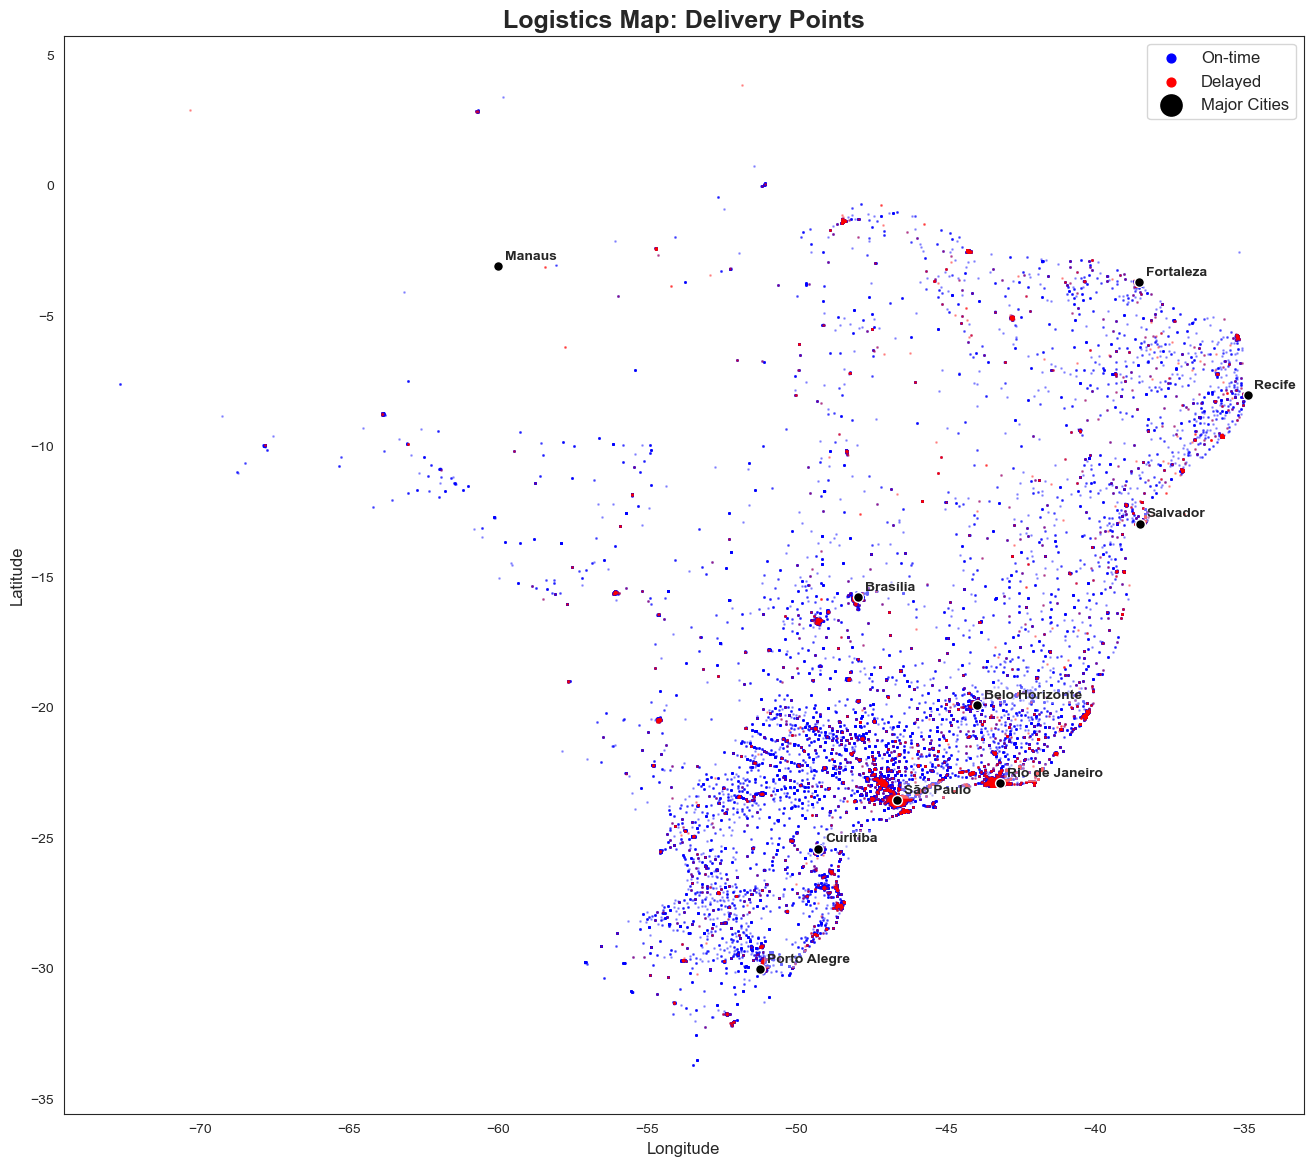

In [10]:
df_map = pd.DataFrame(integrated_df.to_dict('list'))

# Define geographic boundaries for Brazil
# Now 'customer_lat' and 'customer_lng' will be found successfully
lat_mask = (df_map['customer_lat'] <= 5) & (df_map['customer_lat'] >= -35)
lng_mask = (df_map['customer_lng'] <= -35) & (df_map['customer_lng'] >= -75)

# Apply geographic filter
df_map = df_map[lat_mask & lng_mask].copy()

# Segment data by delivery status
# Ensure these columns exist; if you used a different name for 'is_delayed' earlier, update it here
df_ontime = df_map[df_map['is_delayed'] == 0]
df_delayed = df_map[df_map['is_delayed'] == 1]

# Reference coordinates for major Brazilian cities
major_cities = {
    'São Paulo': (-23.55, -46.63), 
    'Rio de Janeiro': (-22.91, -43.17),
    'Brasília': (-15.78, -47.93), 
    'Salvador': (-12.97, -38.50),
    'Fortaleza': (-3.72, -38.52), 
    'Belo Horizonte': (-19.92, -43.94),
    'Curitiba': (-25.42, -49.27), 
    'Manaus': (-3.11, -60.02),
    'Recife': (-8.05, -34.88), 
    'Porto Alegre': (-30.03, -51.23)
}

plt.figure(figsize=(16, 14))

# Plot delivery points
plt.scatter(
    df_ontime['customer_lng'], 
    df_ontime['customer_lat'], 
    alpha=0.3,
    s=1, 
    c='blue', 
    label='On-time', 
    zorder=1
)

plt.scatter(
    df_delayed['customer_lng'], 
    df_delayed['customer_lat'], 
    alpha=0.3, 
    s=1, 
    c='red', 
    label='Delayed', 
    zorder=2
)

# Overlay major cities
for i, (city, coords) in enumerate(major_cities.items()):
    lat, lng = coords
    label = 'Major Cities' if i == 0 else ""
    
    plt.scatter(
        lng, 
        lat, 
        c='black', 
        s=50, 
        edgecolors='white', 
        zorder=5, 
        label=label
    )
    
    plt.annotate(
        city, 
        xy=(lng, lat), 
        xytext=(5, 5), 
        textcoords='offset points',
        fontsize=10, 
        fontweight='bold', 
        bbox=dict(boxstyle='round,pad=0.2', 
        fc='white', 
        alpha=0.4, 
        ec='none'),
        zorder=6
    )

# Map aesthetics
plt.title('Logistics Map: Delivery Points', fontsize=18, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.grid(False)

# Legend configuration
legend = plt.legend(fontsize=12, loc='upper right', frameon=True)
try:
    for i, handle in enumerate(legend.legend_handles): 
        handle.set_alpha(1.0)
        handle.set_sizes([40]) if i < 2 else handle.set_sizes([300])
except AttributeError:
    pass

plt.show()